In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Optimization of Facade Panel Cutting (Nesting Problem)

---

## 1. Introduction
The objective of this project is to demonstrate mathematical intuition and analytical skills through a real-world application in construction: **Facade Panel Nesting**. In facade design, minimizing material waste is a critical economic and environmental goal. This project follows the scientific method to bridge the gap between a practical engineering challenge and its mathematical counterpart.

The guiding principle is to create a functional, well-documented tool that applies geometric and combinatorial logic to reduce material waste.

---

## 2. Problem Formulation
In computer science and mathematics, this is known as the **2D Cutting Stock Problem (CSP)** or a variant of the **Bin Packing Problem**. We are given a set of rectangular facade panels (items) of various dimensions and a large stock sheet (bin) of fixed width and height.

### 2.1 Mathematical Objective
The primary goal is to minimize the "scrap" or "waste" ($W$). Mathematically, if we have $n$ panels to be placed on a sheet of area $A_{sheet}$, the waste is defined as:

$$W = A_{sheet} - \sum_{i=1}^{n} (w_i \times h_i)$$

Where:
* $w_i$ and $h_i$ are the width and height of the $i$-th panel.
* $A_{sheet} = W_{max} \times H_{max}$ is the total area of the raw material.

The efficiency ($\eta$) of the layout can be calculated as a percentage of utilized material:

$$\eta = \left( \frac{\sum_{i=1}^{n} (w_i \times h_i)}{A_{sheet}} \right) \times 100$$

### 2.2 Constraints and Assumptions
To ensure a rigorous mathematical approach, we define the following constraints:
1. **Non-Overlapping:** For any two panels $P_i$ and $P_j$, their interior areas must satisfy $P_i \cap P_j = \emptyset$.
2. **Boundary Constraint:** All panels must stay within the sheet coordinates $(0,0)$ and $(W_{max}, H_{max})$.
3. **Orientation:** Panels may be rotated by $90^\circ$ to improve fit, assuming the material texture/grain allows for it.
4. **Guillotine Cuts:** We assume the cutting machine performs "edge-to-edge" cuts, which simplifies the combinatorial complexity.



---

## 3. Methodology
I will implement and analyze an **Algorithm Implementation** approach. Specifically, I will use a **Greedy Strategy** (First-Fit Decreasing Height) to organize the panels:
1. **Sort:** Arrange panels by height $h$ such that $h_1 \ge h_2 \ge \dots \ge h_n$.
2. **Place:** Use a shelf-stacking logic where each panel is placed in the first available "shelf" that fits its dimensions $w_i$.
3. **Analyze:** Evaluate the computational complexity and the resulting efficiency $\eta$.

### 3.1 Python Implementation
To translate the mathematical model into a functional program, I have defined two core classes: "Panel" and "Sheet". These classes encapsulate the properties of the facade components and the raw material, allowing for automated area and efficiency calculations.

In [2]:
class Panel:
    """Represents an individual facade panel to be cut."""
    def __init__(self, width, height, label=None):
        self.width = width
        self.height = height
        self.label = label
        # Coordinates for placement on the sheet
        self.x = None
        self.y = None
        self.is_rotated = False

    def get_area(self):
        """Calculates the area of the panel."""
        return self.width * self.height

    def rotate(self):
        """Swaps width and height to represent a 90-degree rotation."""
        self.width, self.height = self.height, self.width
        self.is_rotated = not self.is_rotated

class Sheet:
    """Represents the raw material stock sheet."""
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.panels_placed = []

    def get_total_area(self):
        """Calculates the total area of the stock sheet."""
        return self.width * self.height

    def get_used_area(self):
        """Calculates the sum of the areas of all placed panels."""
        return sum(panel.get_area() for panel in self.panels_placed)

    def calculate_efficiency(self):
        """Calculates efficiency (eta) as a percentage."""
        if self.get_total_area() == 0:
            return 0
        return (self.get_used_area() / self.get_total_area()) * 100

### 3.2 Algorithm Preparation: Sorting and Validation

In [3]:
# Defining a stock sheet (standard 2000x3000 mm sheet)
stock_sheet = Sheet(2000, 3000)

# Defining a list of panels
panels_to_cut = [
    Panel(1200, 1500, "Large_A"),
    Panel(1200, 1500, "Large_B"),
    Panel(1200, 800, "Large_C"), 
    Panel(800, 1000, "Extra_D"),  
    Panel(400, 400, "Small_E")
]

# Sort by Height (Primary) then Width (Secondary), both Descending
sorted_panels = sorted(panels_to_cut, key=lambda x: (x.height, x.width), reverse=True)

# Validation & Capacity Check
total_panel_area = sum(p.get_area() for p in sorted_panels)
sheet_area = stock_sheet.get_total_area()

print(f"Sheet Capacity: {sheet_area:,} mm²")
print(f"Total Required Area: {total_panel_area:,} mm²")

if total_panel_area > sheet_area:
    print("Total panel area exceeds sheet capacity. Some panels will not be placed.")
else:
    print("All panels theoretically fit within the area limits.")

Sheet Capacity: 6,000,000 mm²
Total Required Area: 5,520,000 mm²
All panels theoretically fit within the area limits.


### 3.3 The First-Fit Decreasing (FFD) Placement Logic
The core of the nesting algorithm is the placement strategy. I am implementing a **Shelf-based Algorithm**, which is a practical application of geometric logic and coordinate geometry.

1. **Shelf Generation:** The sheet is divided into horizontal levels (shelves). The height of each shelf is determined by the first (tallest) panel placed in it.
2. **First-Fit Rule:** For each panel, the algorithm scans existing shelves to find the first one with sufficient remaining width and height.
3. **Vertical Growth:** If no shelf can accommodate the panel, a new shelf is started above the previous one, provided there is enough vertical height remaining on the stock sheet.
4. **Boundary Validation:** The algorithm ensures that no panel exceeds the sheet width or the total sheet height.

In [4]:
def nest_panels(sheet, panels):
    if not panels:
        return []

    # Reset sheet for a clean run
    sheet.panels_placed = []
    
    # Initialize first shelf
    shelves = [{'y_start': 0, 'height': panels[0].height, 'width_used': 0}]
    unplaced_panels = []

    for panel in panels:
        placed = False
        
        # Try existing shelves
        for shelf in shelves:
            # Check if panel fits in width AND its height doesn't exceed the shelf height
            if (shelf['width_used'] + panel.width <= sheet.width) and (panel.height <= shelf['height']):
                panel.x = shelf['width_used']
                panel.y = shelf['y_start']
                shelf['width_used'] += panel.width
                sheet.panels_placed.append(panel)
                placed = True
                break
        
        # If no shelf fits, create a new one
        if not placed:
            last_shelf = shelves[-1]
            new_y_start = last_shelf['y_start'] + last_shelf['height']
            
            if new_y_start + panel.height <= sheet.height:
                new_shelf = {'y_start': new_y_start, 'height': panel.height, 'width_used': panel.width}
                panel.x = 0
                panel.y = new_y_start
                shelves.append(new_shelf)
                sheet.panels_placed.append(panel)
                placed = True
        
        if not placed:
            unplaced_panels.append(panel)
            
    return unplaced_panels

# Execute and analyze
unplaced = nest_panels(stock_sheet, sorted_panels)

print(f"--- Results ---")
print(f"Placed: {len(stock_sheet.panels_placed)} | Unplaced: {len(unplaced)}")
print(f"Efficiency: {stock_sheet.calculate_efficiency():.2f}%")

# Print coordinates to see how Large_C was handled
for p in stock_sheet.panels_placed:
    print(f"{p.label} placed at ({p.x}, {p.y})")

--- Results ---
Placed: 4 | Unplaced: 1
Efficiency: 76.00%
Large_A placed at (0, 0)
Large_B placed at (0, 1500)
Extra_D placed at (1200, 0)
Small_E placed at (1200, 1500)


> **Conclusion:** While the total area of the panels (5,520,000 mm²) is less than the stock sheet area (6,000,000 mm²), the shelf-based FFD algorithm failed to place all items. Crucially, these panels are geometrically capable of being fitted within the sheet boundaries, but the current "Shelf" logic creates artificial constraints by locking vertical space based on the tallest panel in a row. This demonstrates that while the shelf method is computationally simple, it is inefficient for varied dimensions, as it misses "pockets" of space that a more flexible nesting logic would be able to utilize.

### 3.4 Visualization of Nesting Results
To validate the efficiency of the First-Fit Decreasing (FFD) algorithm and identify specific areas of material waste, I have implemented a visualization tool using matplotlib. This graphical representation allows us to see the "shelf" structures and the empty "pockets" of space that were geometrically available but remained unused due to the algorithmic constraints identified in the previous section.

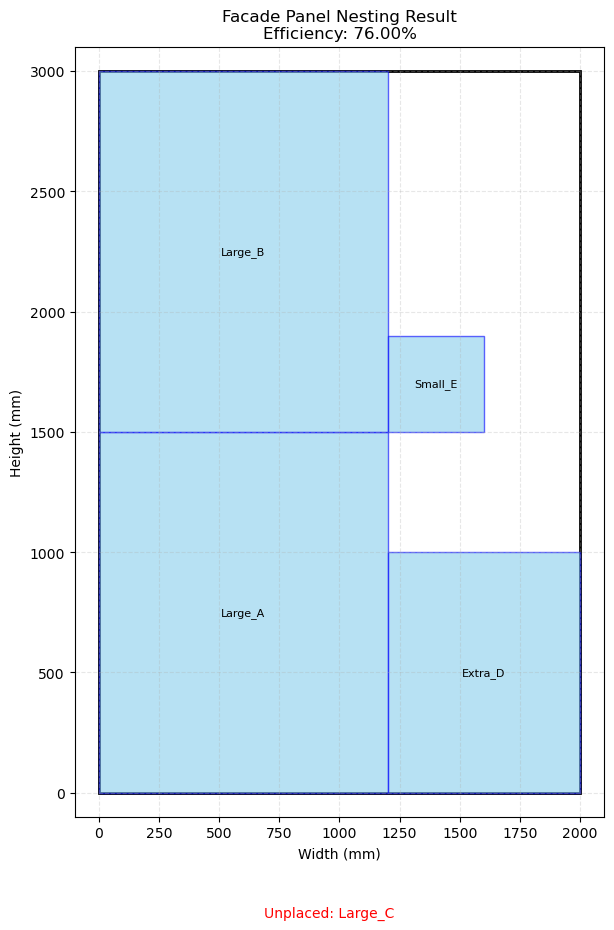

In [6]:
def visualize_nesting(sheet, unplaced_panels):
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # Draw the Stock Sheet boundary
    sheet_rect = patches.Rectangle((0, 0), sheet.width, sheet.height, 
                                   linewidth=2, edgecolor='black', facecolor='none', label='Stock Sheet')
    ax.add_patch(sheet_rect)
    
    # Draw each placed panel
    for panel in sheet.panels_placed:
        # Create a rectangle for each panel
        rect = patches.Rectangle((panel.x, panel.y), panel.width, panel.height, 
                                 linewidth=1, edgecolor='blue', facecolor='skyblue', alpha=0.6)
        ax.add_patch(rect)
        
        # Add label in the center of the panel
        plt.text(panel.x + panel.width/2, panel.y + panel.height/2, panel.label, 
                 ha='center', va='center', fontsize=8)

    # Setting plot limits and labels
    plt.xlim(-100, sheet.width + 100)
    plt.ylim(-100, sheet.height + 100)
    ax.set_aspect('equal')
    plt.title(f"Facade Panel Nesting Result\nEfficiency: {sheet.calculate_efficiency():.2f}%")
    plt.xlabel("Width (mm)")
    plt.ylabel("Height (mm)")
    
    # Show unplaced panels as text for context
    if unplaced_panels:
        unplaced_text = "Unplaced: " + ", ".join([p.label for p in unplaced_panels])
        plt.figtext(0.5, 0.01, unplaced_text, wrap=True, horizontalalignment='center', fontsize=10, color='red')

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Run the visualization
visualize_nesting(stock_sheet, unplaced)